In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
path='https://raw.githubusercontent.com/microsoft/ML-For-Beginners/main/4-Classification/data/cuisines.csv'

df = pd.read_csv(path)
df.head()

,Unnamed: 0,cuisine,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,65,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,66,indian,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,67,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,68,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,69,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2448 entries, 0 to 2447
Columns: 385 entries, Unnamed: 0 to zucchini
dtypes: int64(384), object(1)
memory usage: 7.2+ MB


<Axes: ylabel='cuisine'>

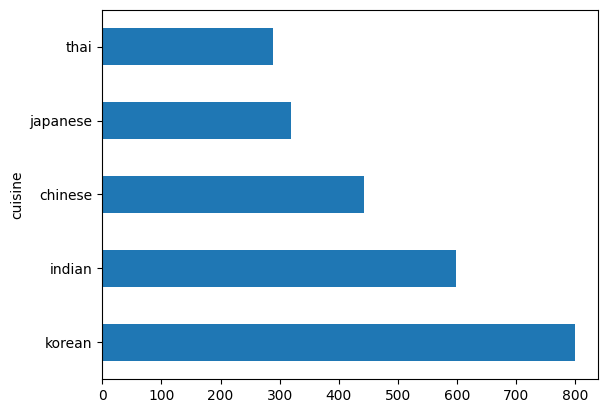

In [33]:
df.cuisine.value_counts().plot.barh()

In [42]:
#create a df for each cuisine
thai_df = df[(df.cuisine == 'thai')]
japanes_df = df[(df.cuisine == 'japanese')]
chinese_df = df[(df.cuisine == 'chinese')]
indian_df = df[(df.cuisine == 'indian')]
korean_df = df[(df.cuisine == 'korean')]

In [43]:
print(f"Thai recipes -> thai_df: {thai_df.shape}")
print(f"Japanese recipes -> japanes_df: {japanes_df.shape}")
print(f"Chinese recipes -> chinese_df: {chinese_df.shape}")
print(f"indian recipes -> indian_df: {indian_df.shape}")
print(f"korean recipes -> korean_df: {korean_df.shape}")

Thai recipes -> thai_df: (289, 385)
Japanese recipes -> japanes_df: (320, 385)
Chinese recipes -> chinese_df: (442, 385)
indian recipes -> indian_df: (598, 385)
korean recipes -> korean_df: (799, 385)


In [ ]:
#kola engridient kanchofo fch7al mn recipe sta3melnah by the sum of ones li kinin f column dyalo
def create_ingredient_df(df):
    # 1. Remove non-ingredient columns
    ingredients_only = df.drop(columns=['cuisine', 'Unnamed: 0'])
    
    # 2. Count how many recipes contain each ingredient
    ingredient_counts = ingredients_only.sum()  # Sum down the columns
    
    # 3. Convert to DataFrame
    ingredient_df = ingredient_counts.to_frame('value')
    
    # 4. Remove ingredients that never appear (0 count)
    ingredient_df = ingredient_df[ingredient_df['value'] > 0]
    
    # 5. Sort by frequency (most common first)
    ingredient_df = ingredient_df.sort_values('value', ascending=False)
    
    return ingredient_df

<Axes: >

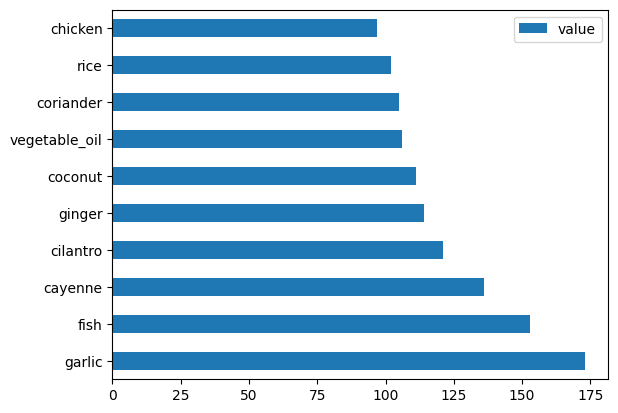

In [ ]:
#Each recipe is represented as a row with 0s and 1s for ingredients
thai_ingredient_df = create_ingredient_df(thai_df)
thai_ingredient_df.head(10).plot.barh()
#fkola dawla kanchoufo lengredients li kayst3mlo w fch7al mn recipe tst3ml kola wa7ed

<Axes: >

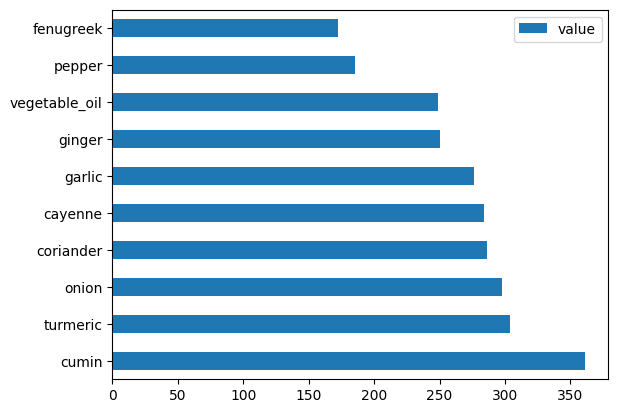

In [41]:
indian_ingredient_df = create_ingredient_df(indian_df)
indian_ingredient_df.head(10).plot.barh()

<Axes: >

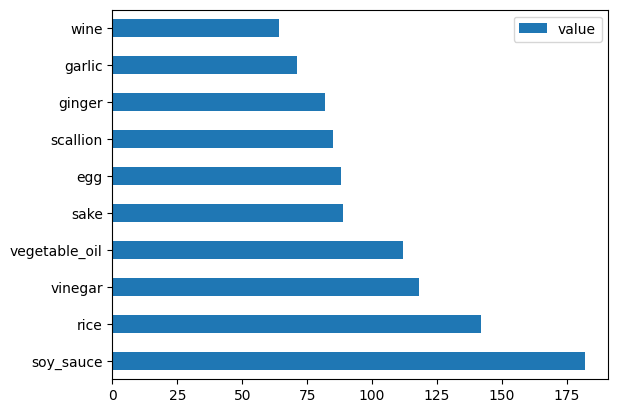

In [45]:
japanese_ingredient_df = create_ingredient_df(japanes_df)
japanese_ingredient_df.head(10).plot.barh()

In [50]:
#removing common ingredients that appear in many different cuisines because they don't help distinguish between them.
# Features (X) - What we use to predict
feature_df = df.drop(['cuisine', 'Unnamed: 0', 'rice', 'garlic', 'ginger'], axis=1)

# Labels (y) - What we're trying to predict
labels_df = df.cuisine  # "thai", "japanese", etc.
print("Features shape:", feature_df.shape)
print("Features columns:", feature_df.columns.tolist()[:10])  # First 10
print("\nLabels:", labels_df.unique())
feature_df.head()


Features shape: (2448, 380)
Features columns: ['almond', 'angelica', 'anise', 'anise_seed', 'apple', 'apple_brandy', 'apricot', 'armagnac', 'artemisia', 'artichoke']

Labels: ['indian' 'thai' 'chinese' 'japanese' 'korean']


,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,artichoke,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [60]:
#imbalanced dataset -> smote
from imblearn.over_sampling import SMOTE
oversample = SMOTE()
transformed_feature_df, transformed_label_df = oversample.fit_resample(feature_df,labels_df)


In [61]:
print(f'new label count :{transformed_lable_df.value_counts()}')
print(f'old label count:{labels_df.value_counts()}')

new label count :cuisine
indian      799
thai        799
chinese     799
japanese    799
korean      799
Name: count, dtype: int64
old label count:cuisine
korean      799
indian      598
chinese     442
japanese    320
thai        289
Name: count, dtype: int64


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    transformed_feature_df, 
    transformed_label_df, 
    test_size=0.3,
    random_state=42  # Added for reproducibility
)

In [68]:
# 2. Create and train the logistic regression model
lr = LogisticRegression(multi_class='ovr', solver='liblinear')
model = lr.fit(X_train, np.ravel(y_train))

# 3. Evaluate the model
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy:.4f}")  # Better formatting
print(f"Accuracy: {accuracy:.2%}")  # As percentage
print("Accuracy is {}".format(accuracy)) 


Accuracy: 0.7940
Accuracy: 79.40%
Accuracy is 0.7939949958298582


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [70]:
print(f'ingredients: {X_test.iloc[50][X_test.iloc[50]]!=0}.keys())')
print(f'cuisine: {y_test.iloc[50]}')

ingredients: almond    False
almond    False
almond    False
almond    False
almond    False
          ...  
almond    False
almond    False
almond    False
almond    False
almond    False
Name: 3651, Length: 380, dtype: bool.keys())
cuisine: thai


/tmp/ipython-input-2434078426.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'ingredients: {X_test.iloc[50][X_test.iloc[50]]!=0}.keys())')


In [71]:
test = X_test.iloc[50].values.reshape(-1,1).T
proba = model.predict_proba(test)
classes = model.classes_
resultdf = pd.DataFrame(data=proba, columns=classes)

toppred = resultdf.T.sort_values(by=[0], ascending=[False])
toppred.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


,0
thai,0.683981
chinese,0.242341
korean,0.042109
japanese,0.030653
indian,0.000916


In [72]:
y_pred = model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

     chinese       0.73      0.66      0.69       236
      indian       0.89      0.89      0.89       245
    japanese       0.75      0.81      0.78       231
      korean       0.84      0.77      0.80       242
        thai       0.76      0.84      0.80       245

    accuracy                           0.79      1199
   macro avg       0.79      0.79      0.79      1199
weighted avg       0.79      0.79      0.79      1199

